# TP2 — Visión por Computadora 1
## Detector de máximo enfoque en un video mediante análisis espectral

Integrantes:
- Julián Barceló
- Jonatan Mild
- Víctor Hugo Astorga
- Roberto Manuel Briend
- Valentín Torres

---

### Objetivo

Implementar un detector de máximo enfoque sobre un video (focus_video.mov) aplicando técnicas de análisis espectral, similares a las que utilizan las cámaras digitales modernas para determinar cuándo una escena está enfocada.

Se implementa la métrica FM (Frequency Domain Image Blur Measure) propuesta en el paper "Image Sharpness Measure for Blurred Images in Frequency Domain" (De, K. & Masilamani, V.) y se la evalúa sobre tres experimentos:

1. Medición sobre todo el frame.
2. Medición sobre una ROI centrada (5% o 10% del área total del frame).
3. Medición sobre una matriz de enfoque compuesta por una grilla de N×M regiones equiespaciadas (se prueba con al menos 3 configuraciones distintas).

Para cada experimento se presenta:
- La curva (o curvas) de evolución de la métrica frame a frame.
- Un algoritmo de detección automática que determina la región de máximo enfoque (no un único frame), marcándola sobre la curva y devolviendo sus límites (frame de inicio, frame de fin y frame de pico).

Como puntos opcionales se agregan:
- Unsharp masking para ampliar la región de enfoque detectada en los bordes (zona de transición enfocado/desenfocado).
- Comparación contra una métrica de enfoque alternativa (Gradient Energy) para contrastar comportamientos.
- Generación de un video anotado que marca en verde los frames enfocados y en rojo los desenfocados, en base a la región detectada automáticamente.


## 0. Setup e imports

In [1]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
import os

%matplotlib inline


In [2]:
# Parámetros generales del análisis
VIDEO_PATH = 'focus_video.mov' # video a analizar
OUTPUT_DIR = 'outs' # carpeta para videos/figuras generadas
os.makedirs(OUTPUT_DIR, exist_ok=True)


## 1. Métrica FM (paper Image Sharpness Measure for Blurred Images in Frequency Domain)

El paper propone una métrica que mide qué tan "enfocada" está una imagen a partir de su contenido espectral: una imagen enfocada tiene energía distribuida en un rango de frecuencias mucho más amplio (más altas frecuencias presentes) que una imagen desenfocada, en la que la energía se concentra cerca del origen del espectro.

El algoritmo, tal como está descripto en el paper, consiste en:

Input: Imagen I de tamaño M×N (se usa en escala de grises).

1. Step 1: Calcular F, la Transformada de Fourier de la imagen I.
2. Step 2: Calcular Fc, corriendo el origen de F al centro (fftshift).
3. Step 3: Calcular AF = abs(Fc), el módulo de la transformada centrada.
4. Step 4: Calcular M = max(AF), el valor máximo de la componente espectral.
5. Step 5: Calcular TH, la cantidad de píxeles de AF cuyo valor supera un umbral thres = M/1000.
6. Step 6: FM = TH / (M*N) es la medida final. A mayor FM, mayor cantidad de frecuencias "significativas" presentes => imagen más enfocada.


In [3]:
def calc_fm(imagen):
    '''
    Calcula la métrica FM (Frequency domain blur Measure) propuesta en el paper
    "Image Sharpness Measure for Blurred Images in Frequency Domain" (De & Masilamani).

    Parametros
    ----------
    imagen : np.ndarray
    Imagen (o región/ROI) en BGR o en escala de grises.

    Retorna
    -------
    float
    Valor de FM. Cuanto mayor, mayor es el enfoque estimado de la imagen.
    '''
    if imagen.ndim == 3:
        imagen = cv.cvtColor(imagen, cv.COLOR_BGR2GRAY)

    # Step 1: Transformada de Fourier 2D
    img_fft = np.fft.fft2(imagen)
    # Step 2: se centra el origen del espectro
    img_fft_shift = np.fft.fftshift(img_fft)
    # Step 3: modulo del espectro centrado
    img_fft_abs = np.abs(img_fft_shift)
    # Step 4: maximo valor espectral
    max_fft = np.max(img_fft_abs)
    # Step 5: cantidad de componentes espectrales por encima de max/1000
    th = np.sum(img_fft_abs > max_fft / 1000)
    # Step 6: metrica normalizada por la cantidad total de pixeles
    fm = th / img_fft_abs.size
    return fm


## 2. Funciones auxiliares

### 2.1 Lectura de frames del video


In [4]:
def leer_frames(video_path):
    '''Lee todos los frames de un video y devuelve la lista junto con sus metadatos.'''
    captura_video = cv.VideoCapture(video_path)
    if not captura_video.isOpened():
        raise IOError(f"No se pudo abrir el archivo de video: {video_path}")

    ancho = int(captura_video.get(cv.CAP_PROP_FRAME_WIDTH))
    alto = int(captura_video.get(cv.CAP_PROP_FRAME_HEIGHT))
    fps = captura_video.get(cv.CAP_PROP_FPS) or 30

    frames = []
    ret = True
    while ret:
        ret, frame = captura_video.read()
        if ret:
            frames.append(frame)
    captura_video.release()
    return frames, alto, ancho, fps


### 2.2 ROI centrada, parametrizada por porcentaje de área

La consigna pide que el área de la ROI sea el 5% o el 10% del área total del frame. Como la ROI se define como un rectángulo cuadrado centrado, si pct_area es la fracción de área deseada, el lado del cuadrado (como fracción del ancho/alto) es sqrt(pct_area), ya que lado^2 = pct_area.


In [5]:
def captura_roi(frame_in, pct_area):
    '''
    Devuelve la región central de la imagen cuya area es aproximadamente
    pct_area * area_total_del_frame, junto con su bounding box (x1,y1,x2,y2).

    Parametros
    ----------
    frame_in : np.ndarray
    Frame de entrada (BGR).
    pct_area : float
    Fraccion del area total que debe ocupar la ROI (ej: 0.05 para 5%).
    '''
    alto, ancho = frame_in.shape[:2]
    lado_pct = np.sqrt(pct_area) # conversion de % de area a % lineal (por lado)

    x1 = int((ancho / 2) - ancho * (lado_pct / 2))
    x2 = int((ancho / 2) + ancho * (lado_pct / 2))
    y1 = int((alto / 2) - alto * (lado_pct / 2))
    y2 = int((alto / 2) + alto * (lado_pct / 2))

    bbox = (x1, y1, x2, y2)
    return frame_in[y1:y2, x1:x2], bbox


def dibuja_roi(frame_in, bbox, color=(0, 255, 0), grosor=2):
    '''Dibuja sobre una copia del frame el rectangulo dado por bbox=(x1,y1,x2,y2).'''
    frame_dibujado = frame_in.copy()
    cv.rectangle(frame_dibujado, (bbox[0], bbox[1]), (bbox[2], bbox[3]), color, grosor)
    return frame_dibujado


### 2.3 Matriz de enfoque: grilla de N×M regiones equiespaciadas (Experimento 3)

Se divide el frame en una grilla de N columnas por M filas de celdas cuadradas, equiespaciadas, y se calcula el FM promedio de todas las celdas para cada frame del video.


In [6]:
def get_grid_regions(frame, N, M, cell_pct=0.05):
    '''
    Devuelve una lista de (region, bbox) correspondientes a una grilla de N x M
    celdas cuadradas equiespaciadas sobre el frame.

    Parametros
    ----------
    frame : np.ndarray
    Frame de entrada.
    N, M : int
    Cantidad de columnas (N) y filas (M) de la grilla.
    cell_pct : float
    Tamano de cada celda, como fraccion del ancho del frame (celdas cuadradas).
    '''
    alto, ancho = frame.shape[:2]
    cell_w = max(2, int(ancho * cell_pct))
    cell_h = max(2, int(alto * cell_pct))

    spacing_x = max(1, (ancho - N * cell_w) // (N + 1))
    spacing_y = max(1, (alto - M * cell_h) // (M + 1))

    regiones = []
    for i in range(M):
        for j in range(N):
            x1 = spacing_x + j * (cell_w + spacing_x)
            y1 = spacing_y + i * (cell_h + spacing_y)
            x2 = min(x1 + cell_w, ancho)
            y2 = min(y1 + cell_h, alto)
            regiones.append((frame[y1:y2, x1:x2], (x1, y1, x2, y2)))
    return regiones


def fm_grid(frame, N, M, cell_pct=0.05):
    '''FM promedio de todas las celdas de la grilla N x M para un frame dado.'''
    regiones = get_grid_regions(frame, N, M, cell_pct)
    valores = [calc_fm(r[0]) for r in regiones]
    return float(np.mean(valores))


## 3. Detección automática de la región de máximo enfoque

Un requisito clave de la consigna es que el algoritmo detecte y devuelva de forma automática los puntos (la región) de máximo enfoque, sin intervención manual. No alcanza con tomar el frame de FM máximo: el enfoque se sostiene durante una región de varios frames, y es esa región la que interesa identificar.

Estrategia utilizada:

1. Se suaviza la curva de FM con un filtro de Savitzky-Golay (scipy.signal.savgol_filter) para atenuar el ruido frame a frame sin desplazar la ubicación del pico.
2. Se ubica el pico de la curva suavizada (argmax).
3. Se define un umbral relativo al pico: umbral = pico - tolerancia * pico (por defecto, tolerancia = 0.10, es decir, 10% de caída respecto del máximo).
4. Se expande la región hacia atrás y hacia adelante del pico mientras la curva suavizada se mantenga por encima del umbral, obteniendo así el frame de inicio y el frame de fin de la región de máximo enfoque.

Este criterio es automático (no requiere fijar a mano un frame), es robusto al ruido de la métrica gracias al suavizado, y refleja fielmente la idea de "región" (y no de "punto") de enfoque.


In [7]:
def detectar_region_enfoque(fm_list, tolerancia=0.10, window=11, polyorder=2):
    '''
    Detecta automaticamente la region de maximo enfoque a partir de una curva de FM.

    Parametros
    ----------
    fm_list : list[float]
    Valores de FM, uno por frame.
    tolerancia : float
    Fraccion de caida respecto del pico que se tolera para seguir considerando
    que un frame pertenece a la region de enfoque (ej: 0.10 = 10%).
    window, polyorder : int
    Parametros del filtro de Savitzky-Golay usado para suavizar la curva.

    Retorna
    -------
    dict con:
    fm_smooth : curva suavizada
    peak_idx, peak_val : frame e intensidad del pico de enfoque
    umbral : umbral usado para delimitar la region
    inicio, fin : indices de frame que delimitan la region de maximo enfoque
    '''
    fm_arr = np.array(fm_list, dtype=float)
    n = len(fm_arr)

    # ventana del filtro: impar y no mayor a la cantidad de muestras
    w = min(window, n - (1 - n % 2))
    if w % 2 == 0:
        w -= 1

    if w < polyorder + 2:
        fm_smooth = fm_arr.copy()
    else:
        fm_smooth = savgol_filter(fm_arr, w, polyorder)

    peak_idx = int(np.argmax(fm_smooth))
    peak_val = float(fm_smooth[peak_idx])
    umbral = peak_val - tolerancia * peak_val

    inicio = peak_idx
    while inicio > 0 and fm_smooth[inicio - 1] >= umbral:
        inicio -= 1

    fin = peak_idx
    while fin < n - 1 and fm_smooth[fin + 1] >= umbral:
        fin += 1

    return {
        "fm_smooth": fm_smooth,
        "peak_idx": peak_idx,
        "peak_val": peak_val,
        "umbral": umbral,
        "inicio": inicio,
        "fin": fin,
    }


### 3.1 Función auxiliar para graficar la curva y la región detectada


In [8]:
def plot_curva_enfoque(fm_list, resultado_deteccion, titulo, ax=None, label='FM'):
    '''Grafica la curva de FM (cruda y suavizada), la region detectada y el pico.'''
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 4))

    n = len(fm_list)
    ax.scatter(range(n), fm_list, s=10, alpha=0.4, label=f'{label} (original)')
    ax.plot(resultado_deteccion['fm_smooth'], color='tab:orange', lw=2, label=f'{label} (suavizado)')

    inicio, fin = resultado_deteccion['inicio'], resultado_deteccion['fin']
    peak_idx = resultado_deteccion['peak_idx']

    ax.axvspan(inicio, fin, color='green', alpha=0.15, label='Región de máx. enfoque')
    ax.axvline(peak_idx, color='red', linestyle='--', lw=1.5, label=f'Pico (frame {peak_idx})')
    ax.axhline(resultado_deteccion['umbral'], color='gray', linestyle=':', lw=1, label='Umbral')

    ax.set_title(titulo)
    ax.set_xlabel('Frame')
    ax.set_ylabel('FM')
    ax.legend(loc='upper right', fontsize=8)
    return ax


## 4. Carga del video y cálculo de la métrica FM base

In [9]:
frames, video_alto, video_ancho, video_fps = leer_frames(VIDEO_PATH)
print(f"Video: {VIDEO_PATH}")
print(f"Cantidad de frames: {len(frames)}")
print(f"Resolucion: {video_ancho}x{video_alto} — FPS: {video_fps:.2f}")


Video: focus_video.mov
Cantidad de frames: 171
Resolucion: 640x360 — FPS: 29.97


## 5. Experimento 1 — Medición sobre todo el frame

Se calcula la métrica FM sobre el frame completo, para cada frame del video.


In [10]:
fm_full = [calc_fm(frame) for frame in frames]
resultado_full = detectar_region_enfoque(fm_full)

print("=== Experimento 1: frame completo ===")
print(f"Frame de pico de enfoque: {resultado_full['peak_idx']} (FM={resultado_full['peak_val']:.5f})")
print(f"Región de máximo enfoque detectada: frames [{resultado_full['inicio']}, {resultado_full['fin']}]")


=== Experimento 1: frame completo ===
Frame de pico de enfoque: 109 (FM=0.02854)
Región de máximo enfoque detectada: frames [80, 115]


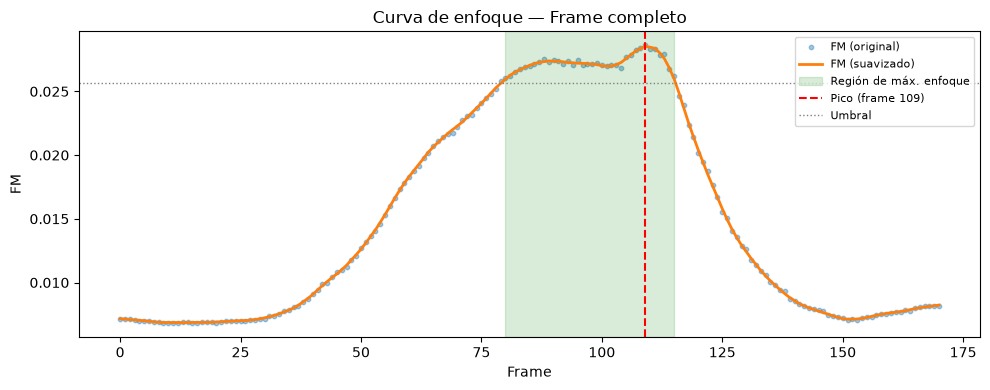

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))
plot_curva_enfoque(fm_full, resultado_full, 'Curva de enfoque — Frame completo', ax=ax)
plt.tight_layout()
plt.show()


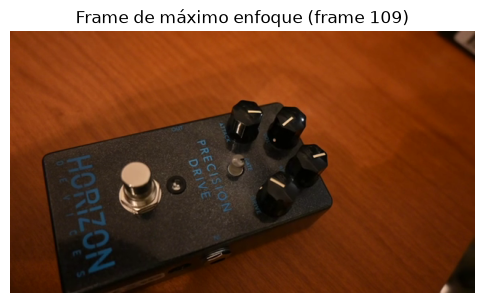

In [12]:
# Se muestra el frame correspondiente al pico de enfoque detectado
frame_pico_full = frames[resultado_full['peak_idx']]
plt.figure(figsize=(6, 4))
plt.imshow(cv.cvtColor(frame_pico_full, cv.COLOR_BGR2RGB))
plt.title(f"Frame de máximo enfoque (frame {resultado_full['peak_idx']})")
plt.axis('off')
plt.show()


## 6. Experimento 2 — Medición sobre una ROI centrada

Se repite la medición, pero ahora solo sobre una región central del frame. Se prueba con 5% y con 10% del área total, tal como habilita la consigna.


In [13]:
resultados_roi = {}

for pct_area in [0.05, 0.10]:
    fm_roi = []
    bbox_roi = None
    for frame in frames:
        roi, bbox = captura_roi(frame, pct_area)
        bbox_roi = bbox
        fm_roi.append(calc_fm(roi))
    resultado = detectar_region_enfoque(fm_roi)
    resultados_roi[pct_area] = {"fm_list": fm_roi, "resultado": resultado, "bbox": bbox_roi}

    print(f"=== Experimento 2: ROI centrada ({int(pct_area * 100)}% del área) ===")
    print(f"Frame de pico de enfoque: {resultado['peak_idx']} (FM={resultado['peak_val']:.5f})")
    print(f"Región de máximo enfoque detectada: frames [{resultado['inicio']}, {resultado['fin']}]")
    print()


=== Experimento 2: ROI centrada (5% del área) ===
Frame de pico de enfoque: 111 (FM=0.46509)
Región de máximo enfoque detectada: frames [105, 113]

=== Experimento 2: ROI centrada (10% del área) ===
Frame de pico de enfoque: 110 (FM=0.35135)
Región de máximo enfoque detectada: frames [99, 113]



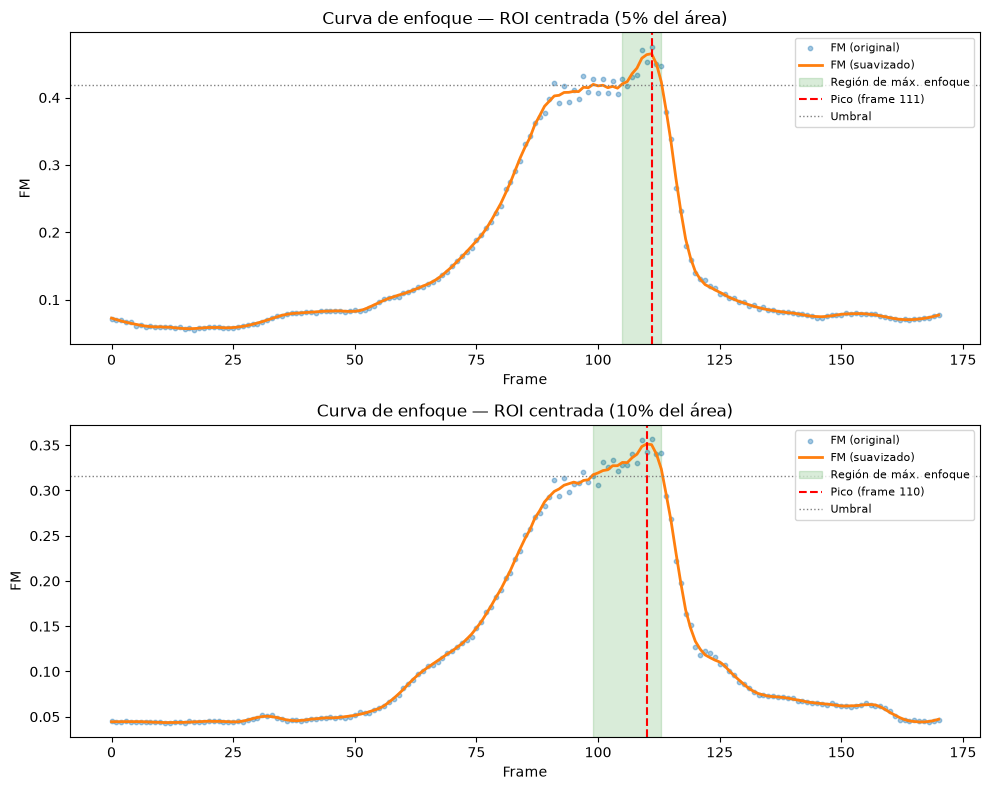

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
for ax, pct_area in zip(axes, [0.05, 0.10]):
    datos = resultados_roi[pct_area]
    plot_curva_enfoque(datos['fm_list'], datos['resultado'],
                       f'Curva de enfoque — ROI centrada ({int(pct_area * 100)}% del área)', ax=ax)
plt.tight_layout()
plt.show()


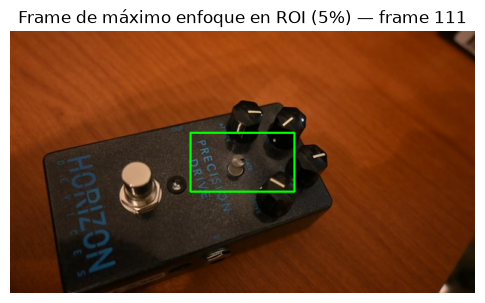

In [15]:
# Frame de maximo enfoque de la ROI al 5%, con el area de la ROI marcada
pct_area = 0.05
datos = resultados_roi[pct_area]
peak_idx = datos['resultado']['peak_idx']
frame_con_roi = dibuja_roi(frames[peak_idx], datos['bbox'])

plt.figure(figsize=(6, 4))
plt.imshow(cv.cvtColor(frame_con_roi, cv.COLOR_BGR2RGB))
plt.title(f"Frame de máximo enfoque en ROI ({int(pct_area * 100)}%) — frame {peak_idx}")
plt.axis('off')
plt.show()


Observación: al focalizar la métrica en el centro de la imagen (donde suele estar el objeto de interés), la curva resulta más sensible: la región de enfoque detectada suele ser más angosta y el contraste entre enfocado/desenfocado más marcado que al medir sobre el frame completo, donde el fondo puede diluir la señal.

## 7. Experimento 3 — Medición sobre una matriz de enfoque (grilla N×M)

Se divide el frame en una grilla de N×M celdas equiespaciadas y se promedia el FM de todas las celdas para cada frame. Se prueban al menos 3 configuraciones distintas de grilla.

In [16]:
configuraciones_grilla = [(3, 3), (7, 5), (9, 6)]
CELL_PCT = 0.03 # tamano de cada celda de la grilla, como % del ancho del frame

resultados_grilla = {}
for (N, M) in configuraciones_grilla:
    fm_grid_list = [fm_grid(frame, N, M, cell_pct=CELL_PCT) for frame in frames]
    resultado = detectar_region_enfoque(fm_grid_list)
    resultados_grilla[(N, M)] = {"fm_list": fm_grid_list, "resultado": resultado}

    print(f"=== Experimento 3: grilla {N}x{M} ===")
    print(f"Frame de pico de enfoque: {resultado['peak_idx']} (FM={resultado['peak_val']:.5f})")
    print(f"Región de máximo enfoque detectada: frames [{resultado['inicio']}, {resultado['fin']}]")
    print()


=== Experimento 3: grilla 3x3 ===
Frame de pico de enfoque: 74 (FM=0.76643)
Región de máximo enfoque detectada: frames [67, 86]

=== Experimento 3: grilla 7x5 ===
Frame de pico de enfoque: 76 (FM=0.70062)
Región de máximo enfoque detectada: frames [62, 105]

=== Experimento 3: grilla 9x6 ===
Frame de pico de enfoque: 68 (FM=0.70702)
Región de máximo enfoque detectada: frames [62, 97]



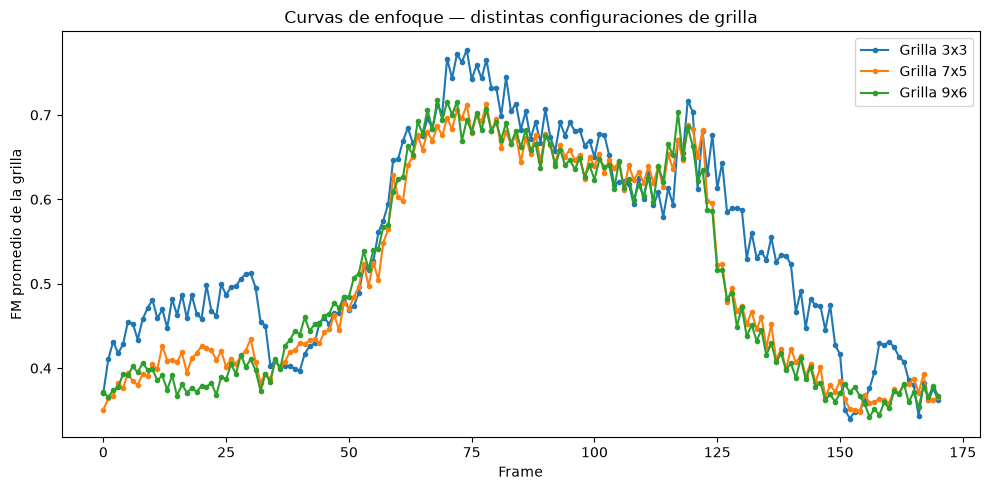

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
for (N, M), datos in resultados_grilla.items():
    ax.plot(datos['fm_list'], marker='.', linestyle='-', label=f'Grilla {N}x{M}')
ax.set_xlabel('Frame')
ax.set_ylabel('FM promedio de la grilla')
ax.set_title('Curvas de enfoque — distintas configuraciones de grilla')
ax.legend()
plt.tight_layout()
plt.show()


Como se menciona en , la medida de enfoque es sensible al tamaño de la ventana analizada: celdas muy pequeñas capturan menos contenido frecuencial útil y agregan ruido a la métrica. A continuación se repite el experimento con la grilla 3×3, pero usando celdas de mayor tamaño, para verificar el efecto.

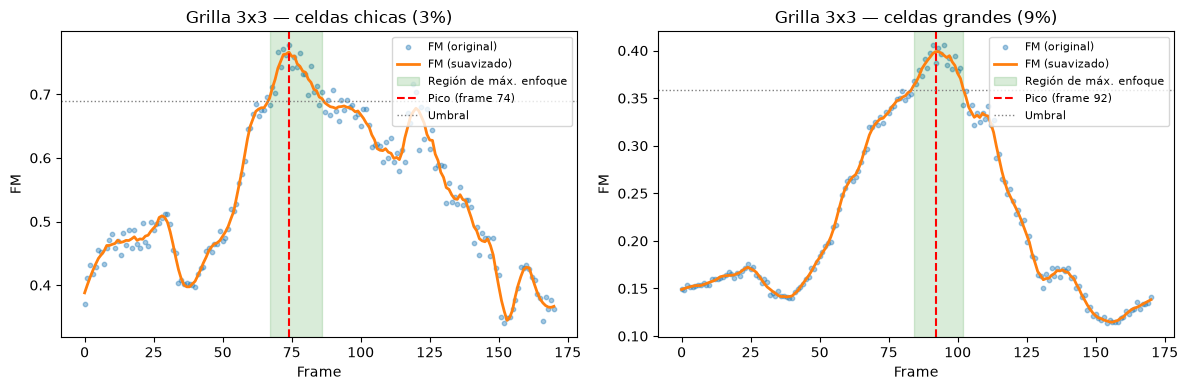

Región detectada (celdas grandes): frames [84, 102]


In [18]:
CELL_PCT_GRANDE = 0.09
fm_grid_3x3_grande = [fm_grid(frame, 3, 3, cell_pct=CELL_PCT_GRANDE) for frame in frames]
resultado_3x3_grande = detectar_region_enfoque(fm_grid_3x3_grande)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_curva_enfoque(resultados_grilla[(3, 3)]['fm_list'], resultados_grilla[(3, 3)]['resultado'],
                   f'Grilla 3x3 — celdas chicas ({int(CELL_PCT * 100)}%)', ax=axes[0], label='FM')
plot_curva_enfoque(fm_grid_3x3_grande, resultado_3x3_grande,
                   f'Grilla 3x3 — celdas grandes ({int(CELL_PCT_GRANDE * 100)}%)', ax=axes[1], label='FM')
plt.tight_layout()
plt.show()

print(f"Región detectada (celdas grandes): frames [{resultado_3x3_grande['inicio']}, {resultado_3x3_grande['fin']}]")


Observación: al aumentar el tamaño de celda (sin cambiar la cantidad de celdas de la grilla) la curva se vuelve considerablemente menos ruidosa y se aproxima al comportamiento observado en los experimentos 1 y 2, confirmando la sensibilidad de la métrica al tamaño de ventana reportada en la literatura.

## 8. Comparación de los tres experimentos

In [19]:
resumen = [
    ("Frame completo", resultado_full['inicio'], resultado_full['peak_idx'], resultado_full['fin']),
    ("ROI 5%", resultados_roi[0.05]['resultado']['inicio'], resultados_roi[0.05]['resultado']['peak_idx'], resultados_roi[0.05]['resultado']['fin']),
    ("ROI 10%", resultados_roi[0.10]['resultado']['inicio'], resultados_roi[0.10]['resultado']['peak_idx'], resultados_roi[0.10]['resultado']['fin']),
    ("Grilla 3x3", resultados_grilla[(3,3)]['resultado']['inicio'], resultados_grilla[(3,3)]['resultado']['peak_idx'], resultados_grilla[(3,3)]['resultado']['fin']),
    ("Grilla 7x5", resultados_grilla[(7,5)]['resultado']['inicio'], resultados_grilla[(7,5)]['resultado']['peak_idx'], resultados_grilla[(7,5)]['resultado']['fin']),
    ("Grilla 9x6", resultados_grilla[(9,6)]['resultado']['inicio'], resultados_grilla[(9,6)]['resultado']['peak_idx'], resultados_grilla[(9,6)]['resultado']['fin']),
]

print(f"{'Experimento':<15}{'Inicio':>10}{'Pico':>10}{'Fin':>10}")
for nombre, inicio, pico, fin in resumen:
    print(f"{nombre:<15}{inicio:>10}{pico:>10}{fin:>10}")


Experimento        Inicio      Pico       Fin
Frame completo         80       109       115
ROI 5%                105       111       113
ROI 10%                99       110       113
Grilla 3x3             67        74        86
Grilla 7x5             62        76       105
Grilla 9x6             62        68        97


Se espera que las regiones detectadas por los distintos experimentos sean consistentes entre sí (deberían coincidir aproximadamente en el mismo rango de frames), lo cual seria una buena señal de que la métrica y el criterio de detección automática son robustos frente a la forma de la región analizada.

## 9. [Opcional] Unsharp masking para ampliar la región de enfoque

La idea de este punto opcional es aplicar unsharp masking (realce de altas frecuencias) sobre los frames que están en la zona de transición entre enfocado y desenfocado (cerca del borde de la región detectada), para intentar "ampliar" artificialmente la región percibida como enfocada.

Es importante notar que el unsharp masking no debe aplicarse indiscriminadamente:
- Si se aplica sobre frames ya muy desenfocados, la métrica puede subir artificialmente sin que la imagen mejore realmente (no hay altas frecuencias reales para recuperar).
- Si se aplica sobre frames que ya están dentro de la región de enfoque, no aporta demasiado, porque ya están nítidos.

Por eso se aplica únicamente en una banda de transición: frames cuya caída de FM respecto del pico está entre dos porcentajes (pct_ini y pct_fin), es decir, ni demasiado lejos del pico ni directamente sobre el pico.

Importante: una vez aplicado el realce, la región resultante se vuelve a delimitar anclada al mismo frame de pico original (no se vuelve a buscar un pico global desde cero). Si en cambio se dejara que el algoritmo busque un nuevo máximo sobre la curva modificada, un frame de la banda de transición cuyo FM quede artificialmente inflado por el realce podría superar al pico real y "correr" toda la región detectada hacia una zona que en realidad no corresponde al enfoque genuino de la escena — el mismo efecto que se buscó evitar al no aplicar unsharp masking sobre frames muy desenfocados.

In [20]:
def unsharp_masking(imagen_in, k_in):
    '''Aplica unsharp masking: realza altas frecuencias restando una version desenfocada.'''
    gauss = cv.GaussianBlur(imagen_in, (7, 7), 0.5)
    return cv.addWeighted(imagen_in, k_in + 1, gauss, -k_in, 0)


def aplicar_unsharp_en_transicion(frames, fm_list, resultado_deteccion, pct_ini=0.25, pct_fin=0.05, k=1.5,
                                 region_frames=None):
    '''
    Recalcula el FM aplicando unsharp masking solo en la banda de transicion entre
    enfocado y desenfocado (frames cuya caida respecto del pico esta entre pct_fin y pct_ini
    del valor pico), evitando aplicarlo tanto en frames muy desenfocados como en frames ya enfocados.

    Si region_frames es una lista de (frame, bbox) - por ejemplo las ROIs ya recortadas -
    se usa esa lista en lugar de frames para aplicar el unsharp.
    '''
    peak_val = resultado_deteccion['peak_val']
    fm_nuevo = []
    for idx, fm_val in enumerate(fm_list):
        caida_relativa = (peak_val - fm_val) / peak_val if peak_val > 0 else 0
        en_banda_transicion = pct_fin <= caida_relativa <= pct_ini
        if en_banda_transicion:
            imagen = region_frames[idx] if region_frames is not None else frames[idx]
            imagen_sharp = unsharp_masking(imagen, k)
            fm_nuevo.append(calc_fm(imagen_sharp))
        else:
            fm_nuevo.append(fm_val)
    return fm_nuevo


def expandir_region_desde_pico(fm_list, peak_idx, peak_val, tolerancia=0.10):
    '''
    A diferencia de detectar_region_enfoque, esta funcion NO busca un nuevo pico:
    parte de un peak_idx / peak_val ya conocidos (por ejemplo, los de la curva original,
    antes de aplicar unsharp masking) y solo expande los limites de la region hacia
    atras/adelante mientras fm_list se mantenga por encima del umbral relativo a ese pico.

    Esto evita que un frame de la banda de transicion, inflado artificialmente por el
    unsharp masking, termine corriendo la deteccion hacia una region que no corresponde
    al enfoque real de la escena.
    '''
    fm_arr = np.array(fm_list, dtype=float)
    n = len(fm_arr)
    umbral = peak_val - tolerancia * peak_val

    inicio = peak_idx
    while inicio > 0 and fm_arr[inicio - 1] >= umbral:
        inicio -= 1

    fin = peak_idx
    while fin < n - 1 and fm_arr[fin + 1] >= umbral:
        fin += 1

    return {"peak_idx": peak_idx, "peak_val": peak_val, "umbral": umbral,
            "inicio": inicio, "fin": fin}


In [21]:
# Se aplica sobre la ROI del 5%, que es donde el efecto se observa mas claramente
pct_area = 0.05
datos_roi5 = resultados_roi[pct_area]
rois_5 = [captura_roi(frame, pct_area)[0] for frame in frames]

fm_roi_sharp = aplicar_unsharp_en_transicion(
    frames=frames,
    fm_list=datos_roi5['fm_list'],
    resultado_deteccion=datos_roi5['resultado'],
    pct_ini=0.25,
    pct_fin=0.05,
    k=1.5,
    region_frames=rois_5,
)
resultado_roi_sharp = expandir_region_desde_pico(
    fm_roi_sharp,
    peak_idx=datos_roi5['resultado']['peak_idx'],
    peak_val=datos_roi5['resultado']['peak_val'],
    tolerancia=0.10,
)

print("Región de enfoque ORIGINAL (ROI 5%): "
      f"[{datos_roi5['resultado']['inicio']}, {datos_roi5['resultado']['fin']}]")
print("Región de enfoque con UNSHARP en transición: "
      f"[{resultado_roi_sharp['inicio']}, {resultado_roi_sharp['fin']}]")


Región de enfoque ORIGINAL (ROI 5%): [105, 113]
Región de enfoque con UNSHARP en transición: [87, 114]


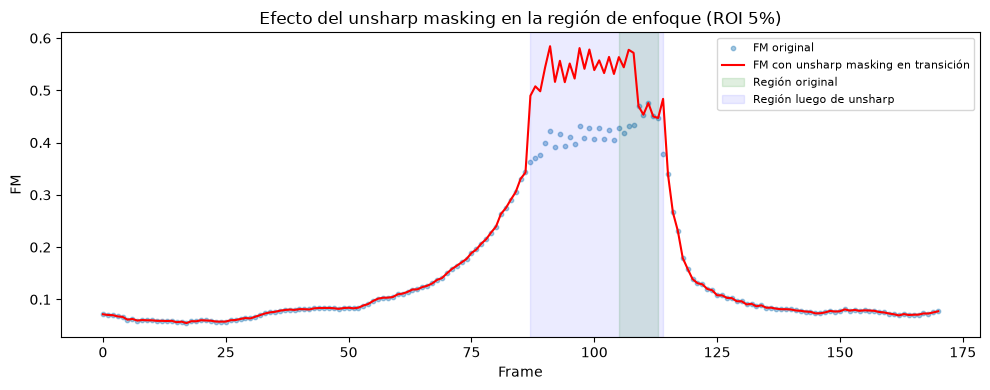

In [22]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(range(len(datos_roi5['fm_list'])), datos_roi5['fm_list'], s=10, alpha=0.4, label='FM original')
ax.plot(fm_roi_sharp, color='red', lw=1.5, label='FM con unsharp masking en transición')
ax.axvspan(datos_roi5['resultado']['inicio'], datos_roi5['resultado']['fin'],
           color='green', alpha=0.12, label='Región original')
ax.axvspan(resultado_roi_sharp['inicio'], resultado_roi_sharp['fin'],
           color='blue', alpha=0.08, label='Región luego de unsharp')
ax.set_xlabel('Frame')
ax.set_ylabel('FM')
ax.set_title('Efecto del unsharp masking en la región de enfoque (ROI 5%)')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()


Observación esperada: al aplicar el realce solo en la banda de transición, la región de enfoque detectada tras el unsharp masking debería ser igual o más ancha que la original, ya que se recupera algo de nitidez percibida en frames cercanos al límite de la zona enfocada, sin inflar artificialmente frames que están completamente desenfocados.

## 10. [Opcional] Comparación con una métrica de enfoque alternativa (Gradient Energy)

A modo de validación cruzada, se compara la métrica FM del paper contra otra métrica de enfoque clásica: la energía del gradiente (suma de los cuadrados de las derivadas de Sobel en X e Y). Una imagen enfocada tiene bordes más marcados y, por lo tanto, mayor energía de gradiente.

In [23]:
def calc_gradient_energy(imagen):
    '''Metrica de enfoque alternativa: energia del gradiente (Sobel en X e Y).'''
    if imagen.ndim == 3:
        imagen = cv.cvtColor(imagen, cv.COLOR_BGR2GRAY)
    gx = cv.Sobel(imagen, cv.CV_64F, 1, 0, ksize=3)
    gy = cv.Sobel(imagen, cv.CV_64F, 0, 1, ksize=3)
    return float(np.sum(gx**2 + gy**2))


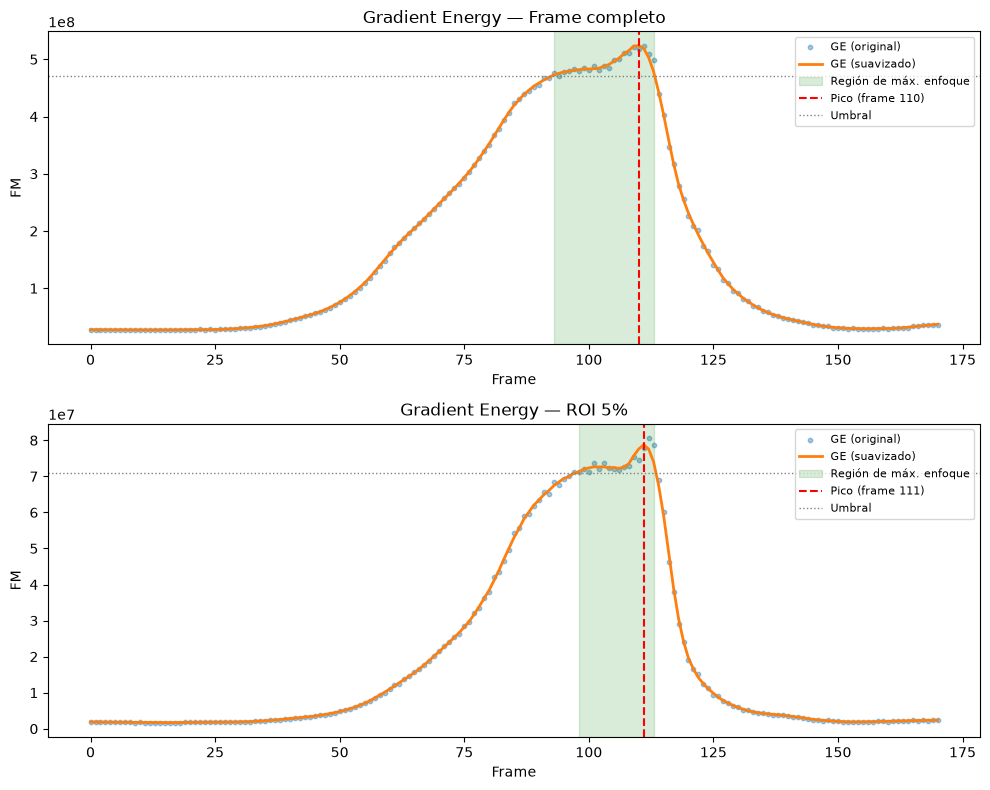

Región (FM, frame completo): [80, 115]
Región (Gradient Energy, frame completo): [93, 113]


In [24]:
ge_full = [calc_gradient_energy(frame) for frame in frames]
ge_roi5 = [calc_gradient_energy(captura_roi(frame, 0.05)[0]) for frame in frames]

resultado_ge_full = detectar_region_enfoque(ge_full)
resultado_ge_roi5 = detectar_region_enfoque(ge_roi5)

fig, axes = plt.subplots(2, 1, figsize=(10, 8))
plot_curva_enfoque(ge_full, resultado_ge_full, 'Gradient Energy — Frame completo', ax=axes[0], label='GE')
plot_curva_enfoque(ge_roi5, resultado_ge_roi5, 'Gradient Energy — ROI 5%', ax=axes[1], label='GE')
plt.tight_layout()
plt.show()

print("Región (FM, frame completo): "
      f"[{resultado_full['inicio']}, {resultado_full['fin']}]")
print("Región (Gradient Energy, frame completo): "
      f"[{resultado_ge_full['inicio']}, {resultado_ge_full['fin']}]")


Observación: si ambas métricas (FM y Gradient Energy) detectan una región de enfoque similar, esto da mayor confianza en que la región identificada corresponde efectivamente al momento en que la escena está en foco, y no a un artefacto propio de una única métrica.

## 11. [Opcional] Generación de un video anotado

Como entregable adicional se genera un video donde cada frame se marca con un recuadro verde si pertenece a la región de máximo enfoque detectada automáticamente, o rojo en caso contrario. Esto permite validar visualmente, reproduciendo el video, que la detección automática es coherente con lo que se observa a simple vista.

In [29]:
def construir_video_anotado(frames, resultado_deteccion, salida, fps=30.0, bbox=None,
                             color_ok=(0, 255, 0), color_no_ok=(0, 0, 255)):
    '''
    Genera un video anotando cada frame como enfocado/desenfocado segun la region
    devuelta por detectar_region_enfoque, y lo guarda en `salida`.
    '''
    inicio, fin = resultado_deteccion['inicio'], resultado_deteccion['fin']
    alto, ancho = frames[0].shape[:2]

    fourcc = cv.VideoWriter_fourcc(*'mp4v')
    out = cv.VideoWriter(salida, fourcc, fps, (ancho, alto))

    for idx, frame in enumerate(frames):
        f = frame.copy()
        enfocado = inicio <= idx <= fin
        color = color_ok if enfocado else color_no_ok

        if bbox is not None:
            cv.rectangle(f, (bbox[0], bbox[1]), (bbox[2], bbox[3]), color, 3)
        else:
            cv.rectangle(f, (5, 5), (ancho - 5, alto - 5), color, 6)

        texto = "ENFOCADO" if enfocado else "DESENFOCADO"
        cv.putText(f, texto, (10, 30), cv.FONT_HERSHEY_SIMPLEX, 0.8, color, 2, cv.LINE_AA)
        out.write(f)

    out.release()
    print(f"Video generado: {salida}")


In [30]:
# Video anotado usando la deteccion sobre el frame completo
salida_full = os.path.join(OUTPUT_DIR, 'focus_video_anotado_full.mp4')
construir_video_anotado(frames, resultado_full, salida_full, fps=video_fps)

# Video anotado usando la deteccion sobre la ROI del 5%, marcando ademas el recuadro de la ROI
salida_roi = os.path.join(OUTPUT_DIR, 'focus_video_anotado_roi5.mp4')
bbox_roi5 = resultados_roi[0.05]['bbox']
construir_video_anotado(frames, resultados_roi[0.05]['resultado'], salida_roi, fps=video_fps, bbox=bbox_roi5)


Video generado: outs\focus_video_anotado_full.mp4
Video generado: outs\focus_video_anotado_roi5.mp4


## 12. Conclusiones

- La métrica FM propuesta en el paper permite estimar de forma efectiva y sin necesidad de una imagen de referencia el nivel de enfoque de un frame, a partir de la cantidad de componentes espectrales significativos por encima de un umbral relativo al máximo del espectro.
- Medir sobre el frame completo da una idea general del enfoque, pero al restringir la medición a una ROI central la métrica se vuelve más sensible al objeto de interés, generalmente ubicado en el centro de la escena.
- La medición sobre una grilla de regiones (matriz de enfoque) confirma que la métrica es sensible al tamaño de la ventana de análisis: celdas muy chicas agregan ruido, mientras que celdas más grandes (manteniendo la cantidad de celdas) suavizan la curva y la acercan al comportamiento de los experimentos 1 y 2.
- Definir la "región" de máximo enfoque (en lugar de un único frame) mediante suavizado + umbral relativo al pico resultó ser un criterio automático, robusto al ruido de la métrica y consistente entre los distintos experimentos.
- El unsharp masking aplicado exclusivamente en la banda de transición enfocado/desenfocado permite ampliar levemente la región percibida como enfocada, sin inflar artificialmente frames completamente desenfocados.
- Contrastar la métrica FM contra una métrica alternativa (Gradient Energy) es una forma simple de validar que la región detectada no es un artefacto de una única métrica, sino un fenómeno real de la escena.
